In [1]:
library(ggplot2)
library(dplyr)
library(lubridate)
library(bslib)
source("Functions/plot_themes.R")
library(stringr)
library(plotly)
library(tidyr)
library(htmlwidgets)
library(dygraphs)
library(xts)
library(tidyverse)
library(googleVis)
library(scales)
library(tidytext)
library(igraph)
library(ggraph)
library(wordcloud)


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching package: ‘lubridate’

The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


Attaching package: ‘bslib’

The following object is masked from ‘package:utils’:

    page


Attaching package: ‘plotly’

The following object is masked from ‘package:ggplot2’:

    last_plot

The following object is masked from ‘package:stats’:

    filter

The following object is masked from ‘package:graphics’:

    layout



Warning message:
package ‘htmlwidgets’ was built under R version 4.4.3 
Warning message:
package ‘dygraphs’ was built under R version 4.4.3 


Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#                                                                             #
# Use stats::lag() to make sure you're not using dplyr::lag(), or you can add #
# conflictRules('dplyr', exclude = 'lag') to your .Rprofile to stop           #
# dplyr from breaking base R's lag() function.                                #
#                                                                             #
# Code in packages is not affected. It's protected by R's

Warning messages:
1: package ‘xts’ was built under R version 4.4.3 
2: package ‘zoo’ was built under R version 4.4.3 


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats 1.0.0     ✔ readr   2.2.0
✔ purrr   1.0.2     ✔ tibble  3.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ plotly::filter() masks dplyr::filter(), stats::filter()
✖ xts::first()     masks dplyr::first()
✖ dplyr::lag()     masks stats::lag()
✖ xts::last()      masks dplyr::last()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


...

Warning message:
package ‘tidytext’ was built under R version 4.4.3 



Attaching package: ‘igraph’

The following objects are masked from ‘package:purrr’:

    compose, simplify

The following object is masked from ‘package:tibble’:

    as_data_frame

The following object is masked from ‘package:tidyr’:

    crossing

The following object is masked from ‘package:plotly’:

    groups

The following objects are masked from ‘package:lubridate’:

    %--%, union

The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union

The following objects are masked from ‘package:stats’:

    decompose, spectrum

The following object is masked from ‘package:base’:

    union



Warning message:
package ‘igraph’ was built under R version 4.4.3 
Warning message:
package ‘ggraph’ was built under R version 4.4.3 


Loading required package: RColorBrewer


Warning message:
package ‘wordcloud’ was built under R version 4.4.3 


In [2]:
reforestacion = read.csv("../Data/Reforestacion.csv")

In [3]:
head(reforestacion)

  X      X_id                               X_uuid           X__version__
1 0 393144147 90953575-a4db-441b-951b-944b72843342 vyVCeasvVkmgvtHGva36kK
2 1 393144147 90953575-a4db-441b-951b-944b72843342 vyVCeasvVkmgvtHGva36kK
3 2 393144147 90953575-a4db-441b-951b-944b72843342 vyVCeasvVkmgvtHGva36kK
4 3 393144927 024bbd2f-d439-4e8c-a140-54ff4572dcd9 vyVCeasvVkmgvtHGva36kK
5 4 393144927 024bbd2f-d439-4e8c-a140-54ff4572dcd9 vyVCeasvVkmgvtHGva36kK
6 5 393144927 024bbd2f-d439-4e8c-a140-54ff4572dcd9 vyVCeasvVkmgvtHGva36kK
    X_submission_time X_validation_status  timestamp      X_submitted_by
1 2024-10-09T16:24:57            Approved 1736873704 monitoreo_pachamama
2 2024-10-09T16:24:57            Approved 1736873704 monitoreo_pachamama
3 2024-10-09T16:24:57            Approved 1736873704 monitoreo_pachamama
4 2024-10-09T16:26:39            Approved 1736873702 monitoreo_pachamama
5 2024-10-09T16:26:39            Approved 1736873702 monitoreo_pachamama
6 2024-10-09T16:26:39            Approved 17

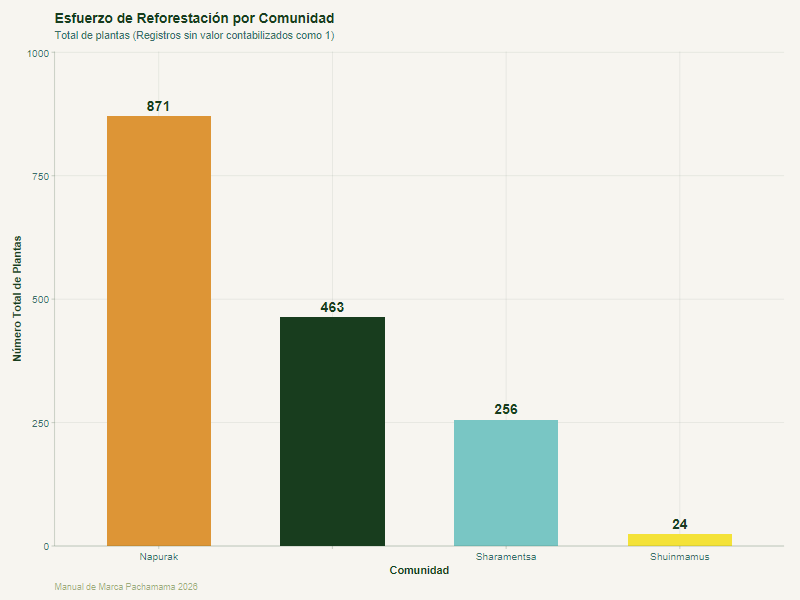

In [ ]:

# 1. Preparar datos de productividad: NA corregidos a 1
refo_comunidad <- reforestacion %>%
  mutate(
    # Convertimos a numérico y reemplazamos NA por 1
    plantas_limpias = replace_na(as.numeric(num_plantas), 1)
  ) %>%
  group_by(Comunidad) %>%
  summarise(Total_Plantas = sum(plantas_limpias), .groups = 'drop')

# 2. Gráfica de barras optimizada
ggplot(refo_comunidad, aes(x = reorder(Comunidad, -Total_Plantas), y = Total_Plantas, fill = Comunidad)) +
  geom_col(width = 0.6, show.legend = FALSE) +
  # Etiquetas sobre las barras
  geom_text(aes(label = Total_Plantas), vjust = -0.5, fontface = "bold", size = 5, color = "#183d1e") +
  # Aplicación de tu paleta institucional
  scale_fill_pacha() + 
  labs(
    title = "Esfuerzo de Reforestación por Comunidad",
    subtitle = "Total de plantas (Registros sin valor contabilizados como 1)",
    x = "Comunidad",
    y = "Número Total de Plantas",
    caption = "Manual de Marca Pachamama 2026"
  ) +
  # Expandimos el eje Y para que las etiquetas no se corten arriba
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
  theme_pachamama()

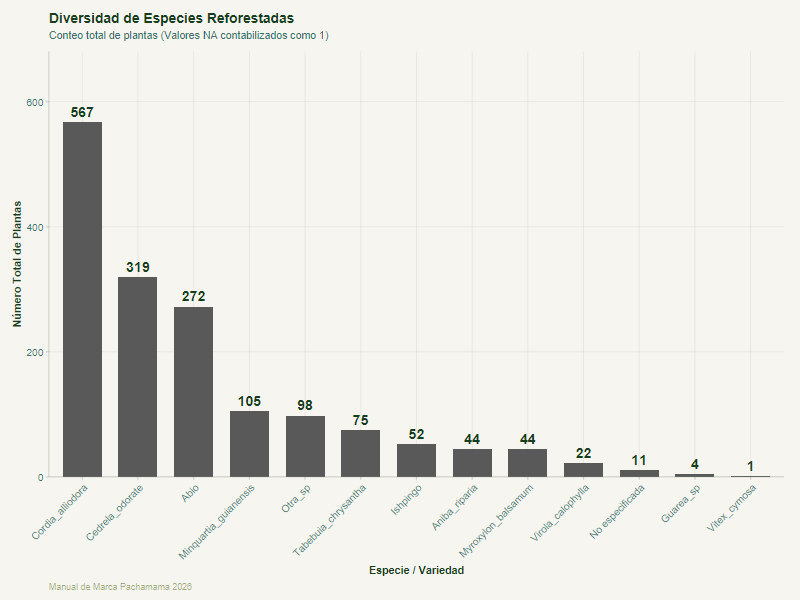

In [12]:

# 1. Preparar datos por Especie: NA corregidos a 1
refo_especie <- reforestacion %>%
  mutate(
    # Reemplazamos NA en especie por una etiqueta clara
    especie_limpia = if_else(is.na(especie) | especie == "", "No especificada", especie),
    # Convertimos num_plantas a numérico y NA a 1
    plantas_conteo = replace_na(as.numeric(num_plantas), 1)
  ) %>%
  group_by(especie_limpia) %>%
  summarise(Total_Plantas = sum(plantas_conteo), .groups = 'drop')

# 2. Generar la gráfica de barras por Especie
ggplot(refo_especie, aes(x = reorder(especie_limpia, -Total_Plantas), y = Total_Plantas)) +
  geom_col(width = 0.7, show.legend = FALSE) +
  # Etiquetas con el total sobre cada barra
  geom_text(aes(label = Total_Plantas), vjust = -0.5, fontface = "bold", size = 5, color = "#183d1e") +
  # Paleta Pachamama
  scale_fill_pacha() + 
  labs(
    title = "Diversidad de Especies Reforestadas",
    subtitle = "Conteo total de plantas (Valores NA contabilizados como 1)",
    x = "Especie / Variedad",
    y = "Número Total de Plantas",
    caption = "Manual de Marca Pachamama 2026"
  ) +
  # Ajuste para evitar que las etiquetas superiores se corten
  scale_y_continuous(expand = expansion(mult = c(0, 0.2))) +
  theme_pachamama() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))